# Entropy

## Real-World Scenario: Cell State Uncertainty in Whole Cell Modeling

A systems biology lab is building a **whole cell model** that simulates gene regulatory networks. They monitor expression levels of key genes across different **cell states** (quiescent, proliferating, stressed, apoptotic). Entropy helps quantify the **uncertainty** in cell state classification from noisy measurements.

We cover all of PML Section 6.1: discrete entropy, binary entropy, DNA sequence logos, cross entropy, joint entropy, conditional entropy, perplexity, and differential entropy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Section 6.1

| Concept | Formula | Eq. |
|---------|---------|-----|
| Entropy | $H(X) = -\sum_k p(X=k) \log_2 p(X=k)$ | 6.1 |
| Binary entropy | $H(\theta) = -\theta \log \theta - (1-\theta)\log(1-\theta)$ | 6.4 |
| Cross entropy | $H_{\text{ce}}(p, q) = -\sum_k p_k \log q_k$ | 6.7 |
| Joint entropy | $H(X, Y) = -\sum_{x,y} p(x,y) \log p(x,y)$ | 6.8 |
| Conditional entropy | $H(Y \mid X) = H(X,Y) - H(X)$ | 6.15 |
| Chain rule | $H(X_1, \ldots, X_n) = \sum_i H(X_i \mid X_1, \ldots, X_{i-1})$ | 6.18 |
| Perplexity | $\text{perplexity}(p) = 2^{H(p)}$ | 6.19 |
| Differential entropy (Gaussian) | $h(X) = \frac{1}{2}\log_2(2\pi e \sigma^2)$ | 6.26 |

## 1. Entropy of Discrete Random Variables (Section 6.1.1)

The entropy of a discrete random variable $X$ with distribution $p$ over $K$ states (Eq. 6.1):

$$H(X) = -\sum_{k=1}^{K} p(X=k) \log_2 p(X=k)$$

Entropy measures **uncertainty**: high entropy means the outcome is hard to predict. The maximum entropy distribution is **uniform** — $H(X) = \log_2 K$ (Eq. 6.2). The minimum entropy is 0, achieved by a delta function that puts all mass on one state.

**Biological context**: A cell can be in one of $K$ states. If all states are equally likely, we have maximum uncertainty about which state a randomly sampled cell is in.

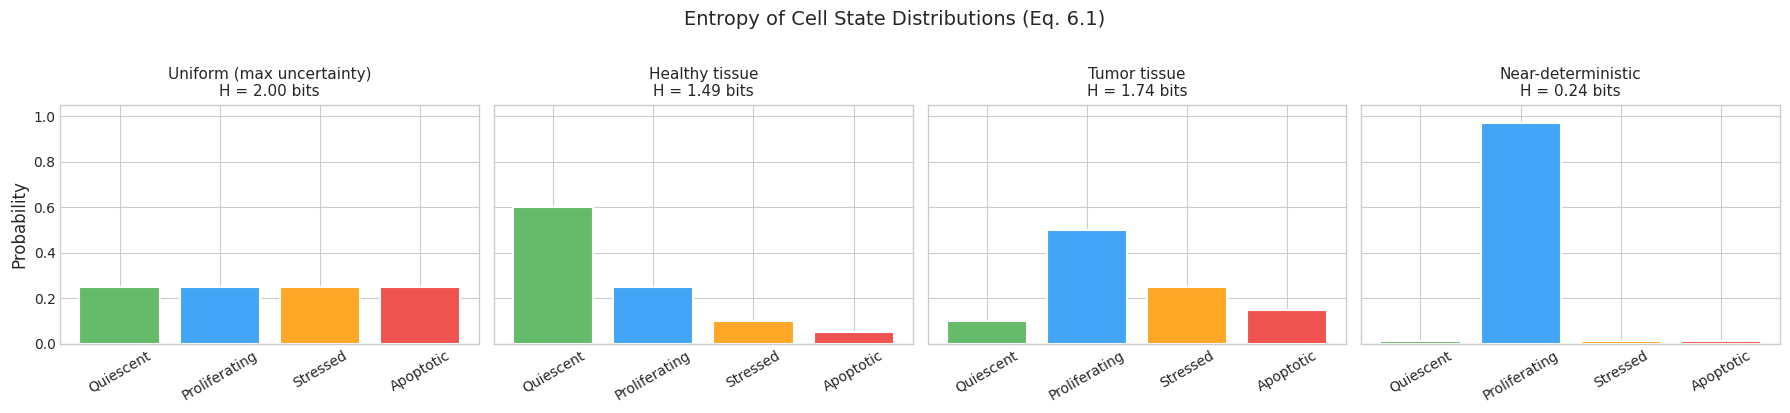

Maximum possible entropy for K=4 states: log₂(4) = 2.00 bits
  Uniform (max uncertainty)     : H = 2.000 bits
  Healthy tissue                : H = 1.490 bits
  Tumor tissue                  : H = 1.743 bits
  Near-deterministic            : H = 0.242 bits


In [2]:
def entropy(p):
    """Discrete entropy H(X) = -sum p_k log2 p_k (Eq. 6.1)."""
    p = np.asarray(p, dtype=float)
    p = p[p > 0]  # 0 log 0 = 0 by convention
    return -np.sum(p * np.log2(p))


# Cell state distributions with varying uncertainty
states = ['Quiescent', 'Proliferating', 'Stressed', 'Apoptotic']
K = len(states)

distributions = {
    'Uniform (max uncertainty)': np.array([0.25, 0.25, 0.25, 0.25]),
    'Healthy tissue': np.array([0.60, 0.25, 0.10, 0.05]),
    'Tumor tissue': np.array([0.10, 0.50, 0.25, 0.15]),
    'Near-deterministic': np.array([0.01, 0.97, 0.01, 0.01]),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
colors = ['#66BB6A', '#42A5F5', '#FFA726', '#EF5350']

for ax, (name, p) in zip(axes, distributions.items()):
    H = entropy(p)
    ax.bar(states, p, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(f'{name}\nH = {H:.2f} bits', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=30)

axes[0].set_ylabel('Probability', fontsize=12)
plt.suptitle('Entropy of Cell State Distributions (Eq. 6.1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'Maximum possible entropy for K={K} states: log₂({K}) = {np.log2(K):.2f} bits')
for name, p in distributions.items():
    print(f'  {name:30s}: H = {entropy(p):.3f} bits')

## 2. Binary Entropy Function (Section 6.1.1)

For a binary random variable $X \in \{0, 1\}$ with $p(X=1) = \theta$ (Eqs. 6.3–6.4):

$$H(\theta) = -[\theta \log_2 \theta + (1-\theta) \log_2 (1-\theta)]$$

The maximum of 1 bit occurs at $\theta = 0.5$ (fair coin). A cell is either proliferating or not — if $\theta = 0.5$, we need exactly 1 bit (one yes/no question) to determine its state.

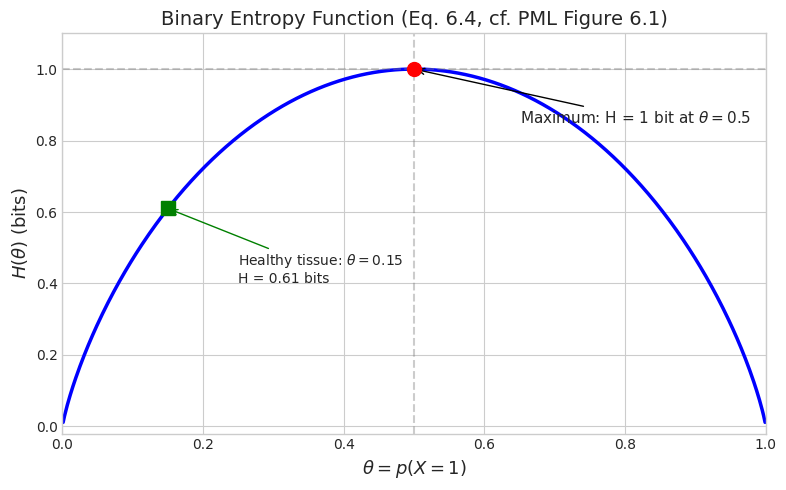

In [3]:
def binary_entropy(theta):
    """Binary entropy H(theta) (Eq. 6.4)."""
    theta = np.clip(theta, 1e-15, 1 - 1e-15)
    return -(theta * np.log2(theta) + (1 - theta) * np.log2(1 - theta))


theta = np.linspace(0.001, 0.999, 500)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(theta, binary_entropy(theta), 'b-', linewidth=2.5)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.4)
ax.plot(0.5, 1.0, 'ro', markersize=10, zorder=5)
ax.annotate('Maximum: H = 1 bit at $\\theta = 0.5$',
            xy=(0.5, 1.0), xytext=(0.65, 0.85), fontsize=11,
            arrowprops=dict(arrowstyle='->', color='black'))

# Mark a biological example
theta_bio = 0.15  # 15% of cells are proliferating
ax.plot(theta_bio, binary_entropy(theta_bio), 'gs', markersize=10, zorder=5)
ax.annotate(f'Healthy tissue: $\\theta = {theta_bio}$\nH = {binary_entropy(theta_bio):.2f} bits',
            xy=(theta_bio, binary_entropy(theta_bio)), xytext=(0.25, 0.4), fontsize=10,
            arrowprops=dict(arrowstyle='->', color='green'))

ax.set_xlabel('$\\theta = p(X = 1)$', fontsize=13)
ax.set_ylabel('$H(\\theta)$ (bits)', fontsize=13)
ax.set_title('Binary Entropy Function (Eq. 6.4, cf. PML Figure 6.1)', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(-0.02, 1.1)
plt.tight_layout()
plt.show()

## 3. DNA Sequence Logos (Section 6.1.1.1)

A position weight matrix (PWM) estimates the empirical distribution of nucleotides $\{A, C, G, T\}$ at each position in aligned DNA sequences (Eqs. 6.5–6.6).

A **sequence logo** scales each column by $R_t = 2 - H_t$, where $H_t$ is the entropy at position $t$ and 2 = $\log_2(4)$ is the max entropy. Highly conserved positions (low entropy, high information) appear tall; variable positions appear short.

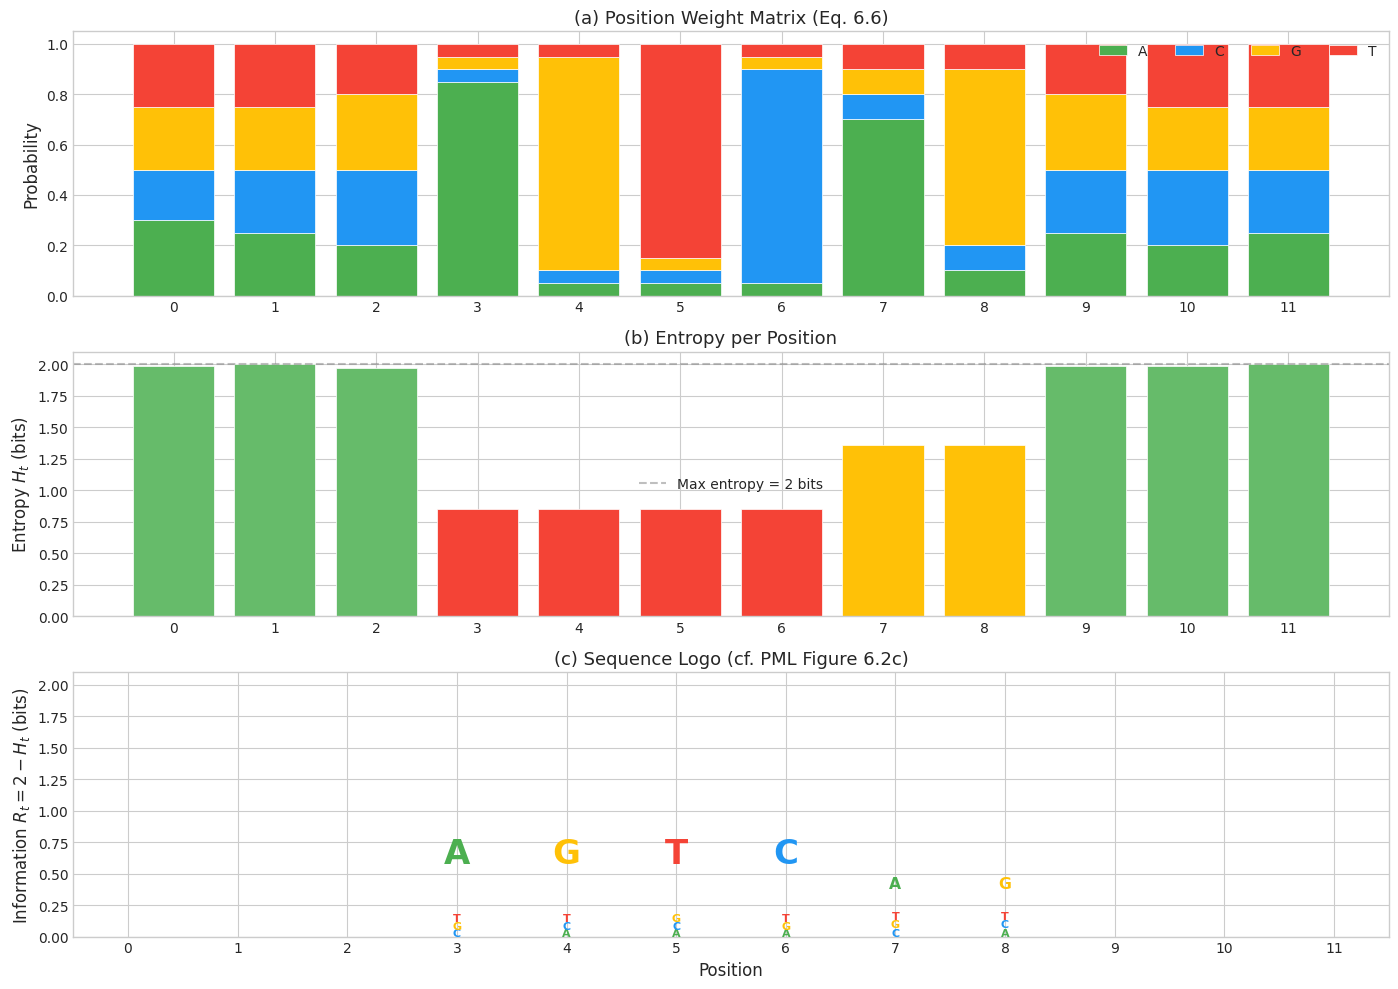

Positions 3-6 are highly conserved (low entropy, tall letters).
These form the core binding motif: A-G-T-C.
Flanking positions are variable (high entropy, short letters).


In [4]:
# Simulate aligned DNA sequences for a transcription factor binding site
np.random.seed(7)
N_seq = 100
L = 12  # positions
alphabet = ['A', 'C', 'G', 'T']

# Design PWM: conserved core (positions 3-8) + variable flanks
pwm = np.array([
    [0.30, 0.20, 0.25, 0.25],  # 0: variable
    [0.25, 0.25, 0.25, 0.25],  # 1: uniform
    [0.20, 0.30, 0.30, 0.20],  # 2: slightly biased
    [0.85, 0.05, 0.05, 0.05],  # 3: conserved A
    [0.05, 0.05, 0.85, 0.05],  # 4: conserved G
    [0.05, 0.05, 0.05, 0.85],  # 5: conserved T
    [0.05, 0.85, 0.05, 0.05],  # 6: conserved C
    [0.70, 0.10, 0.10, 0.10],  # 7: mostly A
    [0.10, 0.10, 0.70, 0.10],  # 8: mostly G
    [0.25, 0.25, 0.30, 0.20],  # 9: variable
    [0.20, 0.30, 0.25, 0.25],  # 10: variable
    [0.25, 0.25, 0.25, 0.25],  # 11: uniform
])

# Compute entropy and information content at each position
H_t = np.array([entropy(pwm[t]) for t in range(L)])
R_t = 2.0 - H_t  # information content (bits)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# (a) PWM as stacked bar
nuc_colors = {'A': '#4CAF50', 'C': '#2196F3', 'G': '#FFC107', 'T': '#F44336'}
bottom = np.zeros(L)
for j, nuc in enumerate(alphabet):
    axes[0].bar(range(L), pwm[:, j], bottom=bottom, color=nuc_colors[nuc],
               label=nuc, edgecolor='white', linewidth=0.5)
    bottom += pwm[:, j]
axes[0].set_ylabel('Probability', fontsize=12)
axes[0].set_title('(a) Position Weight Matrix (Eq. 6.6)', fontsize=13)
axes[0].legend(loc='upper right', ncol=4, fontsize=10)
axes[0].set_xticks(range(L))

# (b) Entropy at each position
bar_colors = ['#F44336' if h < 1.0 else '#FFC107' if h < 1.5 else '#66BB6A' for h in H_t]
axes[1].bar(range(L), H_t, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(2.0, color='gray', linestyle='--', alpha=0.5, label='Max entropy = 2 bits')
axes[1].set_ylabel('Entropy $H_t$ (bits)', fontsize=12)
axes[1].set_title('(b) Entropy per Position', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xticks(range(L))

# (c) Sequence logo: letters scaled by R_t * p(letter)
for t in range(L):
    # Sort nucleotides by frequency (smallest first, drawn at bottom)
    order = np.argsort(pwm[t])
    y_pos = 0
    for j in order:
        height = R_t[t] * pwm[t, j]
        if height > 0.01:
            axes[2].text(t, y_pos + height / 2, alphabet[j],
                        fontsize=max(8, height * 25), fontweight='bold',
                        ha='center', va='center',
                        color=nuc_colors[alphabet[j]])
        y_pos += height

axes[2].set_xlim(-0.5, L - 0.5)
axes[2].set_ylim(0, 2.1)
axes[2].set_ylabel('Information $R_t = 2 - H_t$ (bits)', fontsize=12)
axes[2].set_xlabel('Position', fontsize=12)
axes[2].set_title('(c) Sequence Logo (cf. PML Figure 6.2c)', fontsize=13)
axes[2].set_xticks(range(L))

plt.tight_layout()
plt.show()

print('Positions 3-6 are highly conserved (low entropy, tall letters).')
print('These form the core binding motif: A-G-T-C.')
print('Flanking positions are variable (high entropy, short letters).')

## 4. Cross Entropy (Section 6.1.2)

The cross entropy between distribution $p$ and $q$ (Eq. 6.7):

$$H_{\text{ce}}(p, q) = -\sum_{k=1}^{K} p_k \log q_k$$

It measures the expected number of bits needed to compress data from $p$ using a code based on $q$. Minimized when $q = p$, giving $H_{\text{ce}}(p, p) = H(p)$.

Cross entropy is the loss function used in classification (minimizing it is equivalent to MLE).

In [5]:
def cross_entropy(p, q):
    """Cross entropy H_ce(p, q) = -sum p_k log2 q_k (Eq. 6.7)."""
    p, q = np.asarray(p, dtype=float), np.asarray(q, dtype=float)
    q = np.clip(q, 1e-15, None)
    mask = p > 0
    return -np.sum(p[mask] * np.log2(q[mask]))


# True cell state distribution in healthy tissue
p_true = np.array([0.60, 0.25, 0.10, 0.05])

# Various model predictions
models = {
    'Perfect model (q = p)': p_true.copy(),
    'Uniform model': np.array([0.25, 0.25, 0.25, 0.25]),
    'Overestimates stress': np.array([0.30, 0.20, 0.40, 0.10]),
    'Close but imperfect': np.array([0.55, 0.28, 0.12, 0.05]),
}

H_p = entropy(p_true)
print(f'True distribution p = {p_true}')
print(f'Entropy H(p) = {H_p:.4f} bits (lower bound on cross entropy)\n')
print(f'{"Model":30s} {"H_ce(p,q)":>12s} {"Excess bits":>12s}')
print('-' * 56)
for name, q in models.items():
    hce = cross_entropy(p_true, q)
    print(f'{name:30s} {hce:12.4f} {hce - H_p:12.4f}')

True distribution p = [0.6  0.25 0.1  0.05]
Entropy H(p) = 1.4905 bits (lower bound on cross entropy)

Model                             H_ce(p,q)  Excess bits
--------------------------------------------------------
Perfect model (q = p)                1.4905       0.0000
Uniform model                        2.0000       0.5095
Overestimates stress                 1.9210       0.4305
Close but imperfect                  1.4986       0.0081


## 5. Joint Entropy (Section 6.1.3)

The joint entropy of $(X, Y)$ (Eq. 6.8):

$$H(X, Y) = -\sum_{x,y} p(x,y) \log_2 p(x,y)$$

Key bounds (Eq. 6.10):
- **Upper**: $H(X, Y) \leq H(X) + H(Y)$, with equality iff $X \perp Y$
- **Lower**: $H(X, Y) \geq \max\{H(X), H(Y)\}$

Adding correlated variables reduces the "degrees of freedom" below the sum of individual entropies.

**Example from PML**: Let $X$ = "is even" and $Y$ = "is prime" for integers 1–8.

In [6]:
def joint_entropy(pxy):
    """Joint entropy H(X,Y) from joint pmf table (Eq. 6.8)."""
    pxy = np.asarray(pxy, dtype=float)
    mask = pxy > 0
    return -np.sum(pxy[mask] * np.log2(pxy[mask]))


# PML example: X = is_even, Y = is_prime for n in {1,...,8}
# Joint distribution (Eq. 6.9)
pxy_even_prime = np.array([
    [1/8, 3/8],  # X=0: (Y=0, Y=1)
    [3/8, 1/8],  # X=1: (Y=0, Y=1)
])

H_XY = joint_entropy(pxy_even_prime)
p_X = pxy_even_prime.sum(axis=1)  # marginal of X
p_Y = pxy_even_prime.sum(axis=0)  # marginal of Y
H_X = entropy(p_X)
H_Y = entropy(p_Y)

print('Even/Prime example from PML Section 6.1.3')
print(f'Joint distribution p(X,Y):')
print(f'         Y=0    Y=1')
print(f'  X=0   {pxy_even_prime[0,0]:.3f}  {pxy_even_prime[0,1]:.3f}')
print(f'  X=1   {pxy_even_prime[1,0]:.3f}  {pxy_even_prime[1,1]:.3f}')
print(f'\nMarginals: p(X) = {p_X}, p(Y) = {p_Y}')
print(f'H(X) = {H_X:.2f},  H(Y) = {H_Y:.2f}')
print(f'H(X,Y) = {H_XY:.2f} bits')
print(f'H(X) + H(Y) = {H_X + H_Y:.2f} bits (upper bound if independent)')
print(f'max(H(X), H(Y)) = {max(H_X, H_Y):.2f} bits (lower bound)')
print(f'\nH(X,Y) < H(X)+H(Y) confirms X and Y are NOT independent.')

Even/Prime example from PML Section 6.1.3
Joint distribution p(X,Y):
         Y=0    Y=1
  X=0   0.125  0.375
  X=1   0.375  0.125

Marginals: p(X) = [0.5 0.5], p(Y) = [0.5 0.5]
H(X) = 1.00,  H(Y) = 1.00
H(X,Y) = 1.81 bits
H(X) + H(Y) = 2.00 bits (upper bound if independent)
max(H(X), H(Y)) = 1.00 bits (lower bound)

H(X,Y) < H(X)+H(Y) confirms X and Y are NOT independent.


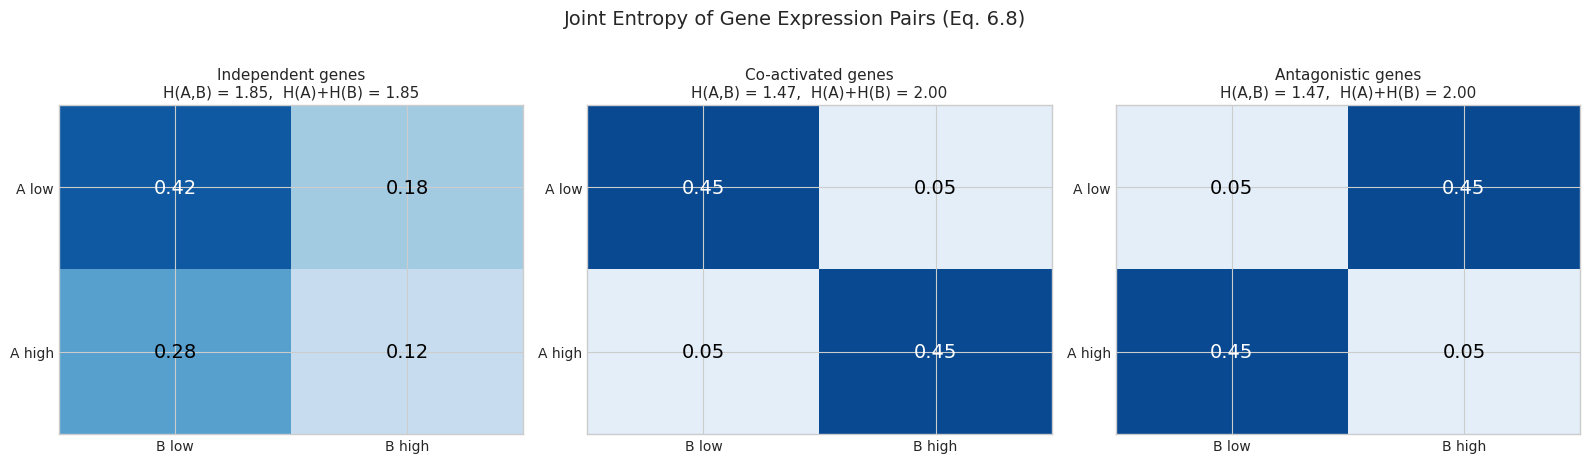

Co-activated/antagonistic genes have lower joint entropy than independent genes.
Correlation reduces the effective degrees of freedom.


In [7]:
# Biological example: joint distribution of two gene markers
# Gene A expression (low/high) and Gene B expression (low/high)
# In a cell, these genes are co-regulated

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

joint_dists = {
    'Independent genes': np.array([[0.42, 0.18], [0.28, 0.12]]),
    'Co-activated genes': np.array([[0.45, 0.05], [0.05, 0.45]]),
    'Antagonistic genes': np.array([[0.05, 0.45], [0.45, 0.05]]),
}

gene_labels_x = ['A low', 'A high']
gene_labels_y = ['B low', 'B high']

for ax, (title, pxy) in zip(axes, joint_dists.items()):
    im = ax.imshow(pxy, cmap='Blues', vmin=0, vmax=0.5, aspect='auto')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{pxy[i,j]:.2f}', ha='center', va='center', fontsize=14,
                   color='white' if pxy[i,j] > 0.3 else 'black')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(gene_labels_y)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(gene_labels_x)
    
    H_j = joint_entropy(pxy)
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)
    ax.set_title(f'{title}\nH(A,B) = {H_j:.2f},  H(A)+H(B) = {entropy(px)+entropy(py):.2f}',
                fontsize=11)

plt.suptitle('Joint Entropy of Gene Expression Pairs (Eq. 6.8)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Co-activated/antagonistic genes have lower joint entropy than independent genes.')
print('Correlation reduces the effective degrees of freedom.')

## 6. Conditional Entropy (Section 6.1.4)

The conditional entropy of $Y$ given $X$ (Eqs. 6.11–6.15):

$$H(Y \mid X) = H(X, Y) - H(X)$$

This is the uncertainty remaining in $Y$ after observing $X$. Key properties:
- If $Y = f(X)$ deterministically: $H(Y \mid X) = 0$
- If $X \perp Y$: $H(Y \mid X) = H(Y)$
- **Conditioning reduces entropy on average** (Eq. 6.16): $H(Y \mid X) \leq H(Y)$

**Chain rule** (Eq. 6.18): $H(X_1, \ldots, X_n) = \sum_{i=1}^{n} H(X_i \mid X_1, \ldots, X_{i-1})$

In [8]:
def conditional_entropy(pxy):
    """H(Y|X) = H(X,Y) - H(X) (Eq. 6.15)."""
    return joint_entropy(pxy) - entropy(pxy.sum(axis=1))


# Biological example: X = gene marker expression, Y = cell state
# A good biomarker has low H(Y|X) — knowing the marker reduces cell state uncertainty

# Joint: rows = marker level (low/medium/high), cols = cell state (quiescent/proliferating/stressed)
pxy_good_marker = np.array([
    [0.30, 0.02, 0.01],  # low marker → mostly quiescent
    [0.05, 0.28, 0.04],  # medium marker → mostly proliferating
    [0.02, 0.03, 0.25],  # high marker → mostly stressed
])

pxy_poor_marker = np.array([
    [0.12, 0.11, 0.10],  # low marker → equally likely states
    [0.12, 0.12, 0.10],  # medium marker → equally likely
    [0.11, 0.11, 0.11],  # high marker → equally likely
])

for name, pxy in [('Good biomarker (Ki-67)', pxy_good_marker),
                   ('Poor biomarker (housekeeping gene)', pxy_poor_marker)]:
    H_Y = entropy(pxy.sum(axis=0))
    H_Y_given_X = conditional_entropy(pxy)
    print(f'{name}:')
    print(f'  H(Cell State) = {H_Y:.3f} bits')
    print(f'  H(Cell State | Marker) = {H_Y_given_X:.3f} bits')
    print(f'  Uncertainty reduction = {H_Y - H_Y_given_X:.3f} bits')
    print(f'  Fraction explained = {(H_Y - H_Y_given_X) / H_Y:.1%}\n')

Good biomarker (Ki-67):
  H(Cell State) = 1.580 bits
  H(Cell State | Marker) = 0.801 bits
  Uncertainty reduction = 0.778 bits
  Fraction explained = 49.3%

Poor biomarker (housekeeping gene):
  H(Cell State) = 1.583 bits
  H(Cell State | Marker) = 1.582 bits
  Uncertainty reduction = 0.001 bits
  Fraction explained = 0.1%



In [9]:
# Verify chain rule: H(X, Y) = H(X) + H(Y|X) (Eq. 6.17)
for name, pxy in [('Good biomarker', pxy_good_marker), ('Poor biomarker', pxy_poor_marker)]:
    H_XY = joint_entropy(pxy)
    H_X = entropy(pxy.sum(axis=1))
    H_Y_given_X = conditional_entropy(pxy)
    print(f'{name}: H(X,Y) = {H_XY:.4f} = H(X) + H(Y|X) = {H_X:.4f} + {H_Y_given_X:.4f} = {H_X + H_Y_given_X:.4f}')

Good biomarker: H(X,Y) = 2.3811 = H(X) + H(Y|X) = 1.5796 + 0.8015 = 2.3811
Poor biomarker: H(X,Y) = 3.1667 = H(X) + H(Y|X) = 1.5848 + 1.5819 = 3.1667


## 7. Perplexity (Section 6.1.5)

The perplexity of a distribution $p$ (Eq. 6.19):

$$\text{perplexity}(p) = 2^{H(p)}$$

Interpretation: the effective number of equally likely outcomes. For a uniform distribution over $K$ states, perplexity = $K$. Lower perplexity means higher predictability.

The cross-entropy perplexity (Eq. 6.21) measures how well model $q$ predicts data from $p$:

$$\text{perplexity}(p, q) = 2^{H_{\text{ce}}(p,q)}$$

In [10]:
# Perplexity of cell state distributions
print(f'{"Distribution":30s} {"H (bits)":>10s} {"Perplexity":>12s} {"Interpretation":>30s}')
print('-' * 85)

for name, p in distributions.items():
    H = entropy(p)
    ppl = 2**H
    interp = f'~{ppl:.1f} effective states'
    print(f'{name:30s} {H:10.3f} {ppl:12.2f} {interp:>30s}')

print(f'\nPerplexity of cross-entropy (model evaluation):')
p_true = np.array([0.60, 0.25, 0.10, 0.05])
for name, q in models.items():
    hce = cross_entropy(p_true, q)
    ppl = 2**hce
    print(f'  {name:30s}: perplexity = {ppl:.2f}')

Distribution                     H (bits)   Perplexity                 Interpretation
-------------------------------------------------------------------------------------
Uniform (max uncertainty)           2.000         4.00          ~4.0 effective states
Healthy tissue                      1.490         2.81          ~2.8 effective states
Tumor tissue                        1.743         3.35          ~3.3 effective states
Near-deterministic                  0.242         1.18          ~1.2 effective states

Perplexity of cross-entropy (model evaluation):
  Perfect model (q = p)         : perplexity = 2.81
  Uniform model                 : perplexity = 4.00
  Overestimates stress          : perplexity = 3.79
  Close but imperfect           : perplexity = 2.83


## 8. Differential Entropy for Continuous Variables (Section 6.1.6)

For a continuous random variable with pdf $p(x)$ (Eq. 6.24):

$$h(X) = -\int p(x) \log p(x) \, dx$$

Unlike discrete entropy, differential entropy can be **negative** (e.g., $U(0, 1/8)$ has $h = -3$ bits).

For a Gaussian $\mathcal{N}(\mu, \sigma^2)$ (Eq. 6.26):

$$h(X) = \frac{1}{2} \log_2(2\pi e \sigma^2)$$

Among all distributions with the same variance, the Gaussian has **maximum** differential entropy (Eq. 6.27).

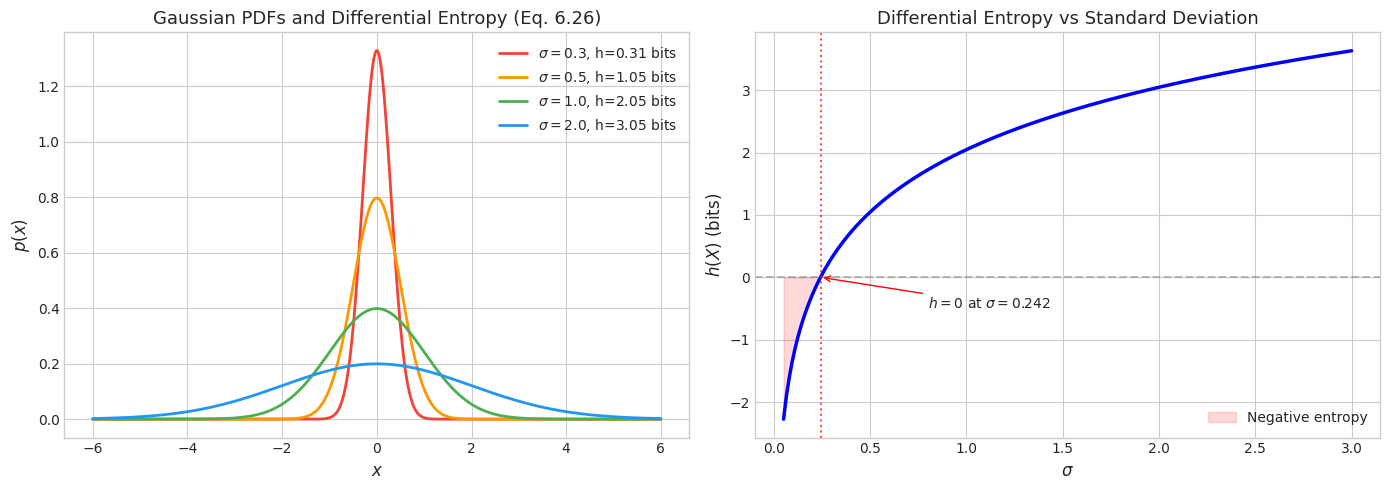

Differential entropy can be negative when sigma < 0.242
This happens because pdf values can exceed 1 for narrow distributions.


In [11]:
def gaussian_diff_entropy(sigma):
    """Differential entropy of N(mu, sigma^2) in bits (Eq. 6.26)."""
    return 0.5 * np.log2(2 * np.pi * np.e * sigma**2)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Gaussian pdfs with different variances
x = np.linspace(-6, 6, 500)
sigmas = [0.3, 0.5, 1.0, 2.0]
colors_sig = ['#F44336', '#FF9800', '#4CAF50', '#2196F3']

for sigma, color in zip(sigmas, colors_sig):
    h = gaussian_diff_entropy(sigma)
    axes[0].plot(x, stats.norm.pdf(x, 0, sigma), color=color, linewidth=2,
               label=f'$\\sigma={sigma}$, h={h:.2f} bits')

axes[0].set_xlabel('$x$', fontsize=12)
axes[0].set_ylabel('$p(x)$', fontsize=12)
axes[0].set_title('Gaussian PDFs and Differential Entropy (Eq. 6.26)', fontsize=13)
axes[0].legend(fontsize=10)

# Right: h(X) as function of sigma
sigma_range = np.linspace(0.05, 3, 200)
h_range = gaussian_diff_entropy(sigma_range)

axes[1].plot(sigma_range, h_range, 'b-', linewidth=2.5)
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].fill_between(sigma_range, h_range, 0, where=(h_range < 0),
                     alpha=0.15, color='red', label='Negative entropy')

# Mark where h = 0: sigma = 1/sqrt(2*pi*e)
sigma_zero = 1 / np.sqrt(2 * np.pi * np.e)
axes[1].axvline(sigma_zero, color='red', linestyle=':', alpha=0.7)
axes[1].annotate(f'$h=0$ at $\\sigma = {sigma_zero:.3f}$',
                xy=(sigma_zero, 0), xytext=(0.8, -0.5), fontsize=10,
                arrowprops=dict(arrowstyle='->', color='red'))

axes[1].set_xlabel('$\\sigma$', fontsize=12)
axes[1].set_ylabel('$h(X)$ (bits)', fontsize=12)
axes[1].set_title('Differential Entropy vs Standard Deviation', fontsize=13)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'Differential entropy can be negative when sigma < {sigma_zero:.3f}')
print('This happens because pdf values can exceed 1 for narrow distributions.')

## Summary

- **Entropy** $H(X)$ measures uncertainty; maximized by the uniform distribution ($H = \log_2 K$), minimized by deterministic distributions ($H = 0$)
- **Binary entropy** peaks at 1 bit when $\theta = 0.5$ (fair coin)
- **DNA sequence logos** use entropy to visualize conservation: $R_t = 2 - H_t$ scales letter height by information content
- **Cross entropy** $H_{\text{ce}}(p, q) \geq H(p)$: using the wrong code $q$ always costs extra bits
- **Joint entropy** satisfies $\max(H(X), H(Y)) \leq H(X,Y) \leq H(X) + H(Y)$
- **Conditional entropy** $H(Y|X) \leq H(Y)$: conditioning never increases uncertainty on average
- **Perplexity** $2^H$ gives the effective number of equally likely outcomes
- **Differential entropy** can be negative; Gaussian has maximum entropy for fixed variance